This is a little intro notebook I made to test some code. It has some visualizers and other notes about the datasets that could be interesting to see

In [1]:
import os
import cv2
import numpy as np
import torch
import torch.utils.data as data
from torch.utils.data import random_split
import matplotlib.pyplot as plt
import datasets

Let's take a look at the ROSE dataset first.

If you look at the datasets.py file, there are dataset classes for OCTA500 and ROSE, to put them in a more usable format.

In [2]:
# create an instance of the class
rose_test_class = datasets.ROSE_Dataset("ROSE_DATA/ROSE/ROSE-1", subsets=["SVC_DVC"], split="test")
rose_train_class = datasets.ROSE_Dataset("ROSE_DATA/ROSE/ROSE-1", subsets=["SVC_DVC"], split="train")

# then we need to make a loader to access the data
rose_test_loader = data.DataLoader(rose_test_class)
rose_train_loader = data.DataLoader(rose_train_class)

rose_test_pairs = rose_test_loader.dataset
rose_train_pairs = rose_train_loader.dataset

Let's take a look at what our dataset looks like now:

Train size: 30
Test size: 9
Image shape: torch.Size([1, 304, 304])
Mask shape: torch.Size([1, 304, 304])


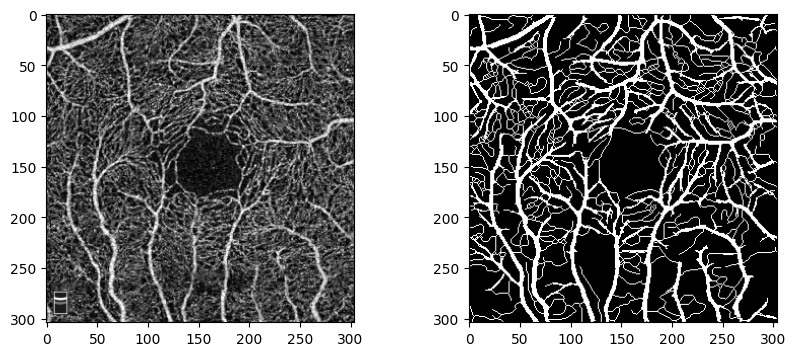

In [3]:
# confirm data dims
print(f"Train size: {len(rose_train_pairs)}")  # expect 30
print(f"Test size: {len(rose_test_pairs)}")    # expect 9

image, mask = rose_train_pairs[0]
print(f"Image shape: {image.shape}")          # expect (1, 304, 304)
print(f"Mask shape: {mask.shape}")            # expect (1, 304, 304)

# convert to numpy arary to print
image = image.squeeze(0).numpy()
mask = mask.squeeze(0).numpy()

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].imshow(image,cmap='gray')
axs[1].imshow(mask,cmap='gray')

Now let's look at the OCTA500 dataset.

This one doesn't have a preset train-test-val split but the literature suggests 160-20-20 so we'll do that

In [4]:
OCTA500_TRAIN_SIZE = 160
OCTA500_TEST_SIZE = 20
OCTA500_VAL_SIZE = 20

# create an instance of the class
OCTA500_set_combined = datasets.OCTA5003M_Dataset('OCTA500_3mm')

# shuffle and split
train_octa500, test_octa500, val_octa500 = data.random_split(
    OCTA500_set_combined, [OCTA500_TRAIN_SIZE, OCTA500_TEST_SIZE, OCTA500_VAL_SIZE], 
    generator=torch.Generator().manual_seed(42))

# then we need to make a loader to access the data
octa_train_loader = data.DataLoader(train_octa500, batch_size=8, shuffle=True)
octa_val_loader = data.DataLoader(val_octa500, batch_size=8, shuffle=False)
octa_test_loader = data.DataLoader(test_octa500, batch_size=8, shuffle=False)

octa_test_pairs = octa_test_loader.dataset
octa_train_pairs = octa_train_loader.dataset
octa_val_pairs = octa_val_loader.dataset

Train size: 20
Test size: 20
Val size: 20
Image shape: torch.Size([1, 304, 304])
Mask shape: torch.Size([1, 304, 304])
Image range: 0.0 - 1.0
Mask unique values: [0 1]


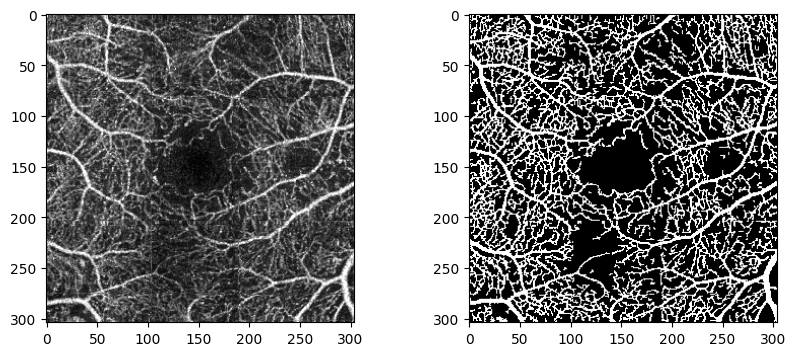

In [5]:
# confirm data dims
print(f"Train size: {len(octa_test_pairs)}")  # expect 160
print(f"Test size: {len(octa_test_pairs)}")  # expect 20
print(f"Val size: {len(octa_val_pairs)}")  # expect 20

image, mask = octa_test_pairs[0]
print(f"Image shape: {image.shape}")          # expect (304, 304)
print(f"Mask shape: {mask.shape}")            # expect (304, 304)
print(f"Image range: {image.min()} - {image.max()}")   # expect 0-255
print(f"Mask unique values: {np.unique(mask)}")  

# lets see an image and label
image = image.squeeze(0).numpy()
mask = mask.squeeze(0).numpy()

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].imshow(image,cmap='gray')
axs[1].imshow(mask,cmap='gray')

In [ ]:
import segmentation_models_pytorch as smp

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

basic_unet = smp.Unet(
    encoder_name="resnet34",        # choose encoder, e.g. mobilenet_v2 or efficientnet-b7
    encoder_weights=None,     # use `imagenet` pre-trained weights for encoder initialization
    in_channels=1,                  # model input channels (1 for gray-scale images, 3 for RGB, etc.)
    classes=1,                      # model output channels (number of classes in your dataset)
).to(device)     

state_dict = torch.load('UNet_res34.pth', map_location=torch.device('cpu'))
basic_unet.load_state_dict(state_dict)
basic_unet.eval()

Using device: cpu


Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

Let's look at how UNet segments images

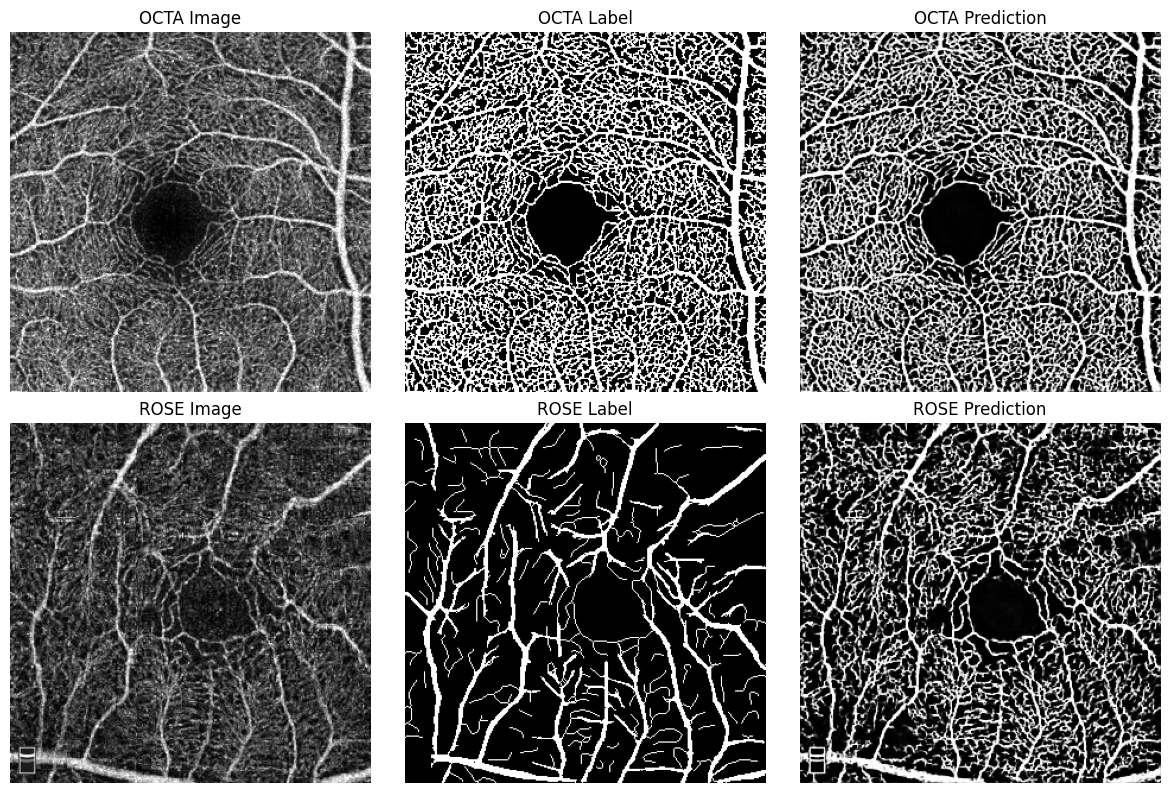

In [ ]:
octa_img, octa_mask = octa_test_pairs[1]
rose_img, rose_mask = rose_test_pairs[1]

with torch.no_grad():
    octa_pred = basic_unet(octa_img.unsqueeze(0).to(device))
    rose_pred = basic_unet(rose_img.unsqueeze(0).to(device))

# change to numpy arrays
octa_pred = torch.sigmoid(octa_pred).squeeze().cpu().numpy()
rose_pred = torch.sigmoid(rose_pred).squeeze().cpu().numpy()

octa_img = octa_img.squeeze(0).cpu().numpy()
octa_mask = octa_mask.squeeze(0).cpu().numpy()
rose_img = rose_img.squeeze(0).cpu().numpy()
rose_mask = rose_mask.squeeze(0).cpu().numpy()

fig, axs = plt.subplots(2, 3, figsize=(12, 8))

# OCTA row
axs[0, 0].imshow(octa_img, cmap="gray")
axs[0, 0].set_title("OCTA Image")
axs[0, 0].axis("off")

axs[0, 1].imshow(octa_mask, cmap="gray")
axs[0, 1].set_title("OCTA Label")
axs[0, 1].axis("off")

axs[0, 2].imshow(octa_pred, cmap="gray")
axs[0, 2].set_title("OCTA Prediction")
axs[0, 2].axis("off")

# ROSE row
axs[1, 0].imshow(rose_img, cmap="gray")
axs[1, 0].set_title("ROSE Image")
axs[1, 0].axis("off")

axs[1, 1].imshow(rose_mask, cmap="gray")
axs[1, 1].set_title("ROSE Label")
axs[1, 1].axis("off")

axs[1, 2].imshow(rose_pred, cmap="gray")
axs[1, 2].set_title("ROSE Prediction")
axs[1, 2].axis("off")

plt.tight_layout()
plt.show()

Now let's do the same for MANet

In [22]:
MANet = smp.MAnet(
    encoder_name="resnet34",        # choose encoder, e.g. mobilenet_v2 or efficientnet-b7
    encoder_weights=None,     # use `imagenet` pre-trained weights for encoder initialization
    in_channels=1,                  # model input channels (1 for gray-scale images, 3 for RGB, etc.)
    classes=1,                      # model output channels (number of classes in your dataset)
).to(device)     

state_dict = torch.load('MANet_res34.pth', map_location=torch.device('cpu'))
MANet.load_state_dict(state_dict)
MANet.eval()

MAnet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, trac

In [ ]:
import torch.nn.functional as F
# have to resize to 320 for MANet to work

octa_img, octa_mask = octa_test_pairs[1]
rose_img, rose_mask = rose_test_pairs[1]

octa_img = F.interpolate(octa_img.unsqueeze(0), size=(320, 320), mode='bilinear', align_corners=False)
octa_mask = F.interpolate(octa_mask.unsqueeze(0).float(), size=(320, 320), mode='nearest').long()
rose_img = F.interpolate(rose_img.unsqueeze(0), size=(320, 320), mode='bilinear', align_corners=False)
rose_mask = F.interpolate(rose_mask.unsqueeze(0).float(), size=(320, 320), mode='nearest').long()

MANet.eval()
with torch.no_grad():
    octa_pred = MANet(octa_img.to(device))
    rose_pred = MANet(rose_img.to(device))

# change to numpy arrays
octa_pred = torch.sigmoid(octa_pred).squeeze().cpu().numpy()
rose_pred = torch.sigmoid(rose_pred).squeeze().cpu().numpy()

octa_img = octa_img.squeeze().cpu().numpy()
octa_mask = octa_mask.squeeze().cpu().numpy()
rose_img = rose_img.squeeze().cpu().numpy()
rose_mask = rose_mask.squeeze().cpu().numpy()

fig, axs = plt.subplots(2, 3, figsize=(12, 8))

# OCTA row
axs[0, 0].imshow(octa_img, cmap="gray")
axs[0, 0].set_title("OCTA Image")
axs[0, 0].axis("off")

axs[0, 1].imshow(octa_mask, cmap="gray")
axs[0, 1].set_title("OCTA Label")
axs[0, 1].axis("off")

axs[0, 2].imshow(octa_pred, cmap="gray")
axs[0, 2].set_title("OCTA Prediction")
axs[0, 2].axis("off")

# ROSE row
axs[1, 0].imshow(rose_img, cmap="gray")
axs[1, 0].set_title("ROSE Image")
axs[1, 0].axis("off")

axs[1, 1].imshow(rose_mask, cmap="gray")
axs[1, 1].set_title("ROSE Label")
axs[1, 1].axis("off")

axs[1, 2].imshow(rose_pred, cmap="gray")
axs[1, 2].set_title("ROSE Prediction")
axs[1, 2].axis("off")

plt.tight_layout()
plt.show()